In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
HS_data['date'] = pd.to_datetime(HS_data['date'])

In [13]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0


#Filter to the winter months

In [10]:
HS_data['winter_DV'] = np.where(HS_data["date"].dt.month.isin([12, 1, 2]),1,0)
display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,1
1,dt4training,2011-02-28,24552000,686144,0,794,1
2,dt4training,2011-03-31,14804728,416464,0,714,0
3,dt4training,2011-04-30,11265320,324456,1,354,0
4,dt4training,2011-05-31,5945904,151104,72,114,0
5,dt4training,2011-06-30,10379712,479264,239,4,0
6,dt4training,2011-07-31,13617528,708472,486,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0
9,dt4training,2011-10-31,11957032,392328,24,223,0


#Create an interaction variable

In [11]:
HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


In [14]:

y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production', 'winter_DV', 'winter_interaction']]
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


In [15]:
xtest = dt4testing.loc[:,['production', 'winter_DV', 'winter_interaction']]
xtest = sm.add_constant(xtest)

# Calculate MAPE score

In [16]:
MAPE_test = dt4testing.copy()
MAPE_test['model1_predicted_revenue'] = model1.predict(xtest)

MAPE_test['pct_error'] = abs((MAPE_test['revenue'] - MAPE_test['model1_predicted_revenue'])/MAPE_test['revenue'])

display(MAPE_test)
MAPE_test['pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction,model1_predicted_revenue,pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400,22205317.42,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128,25185922.91,0.06
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,16509348.78,0.17
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,10705408.70,0.21
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,9401310.32,0.28
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,12619743.01,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,15751307.84,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,14589288.11,0.18
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,15105525.23,0.20
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,11189880.71,0.20


np.float64(0.15896219012848184)

#Create a forecast model with a winter DV

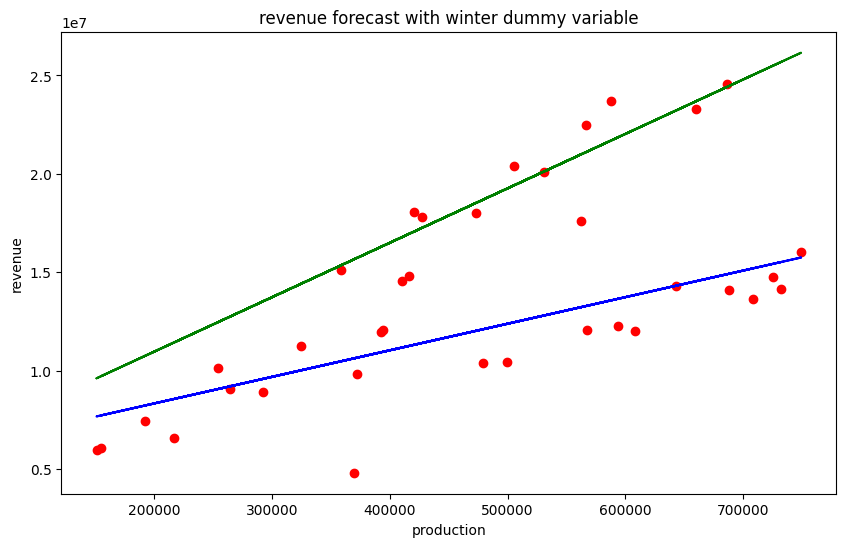

In [23]:
plt.figure(figsize = (10,6))

plt.title('revenue forecast with winter dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

#step 1 for visualizing a regression with dummy variables is to scatter plot the actial datapoints

plt.scatter(dt4training['production'], dt4training['revenue'], color='red')

#step 2 is to extract the coefficients from our model
intercept, production_coefficient, winter_DV_intercept, winter_coefficient = model1.params

#Step 3 is to create lines for winter and non winter
non_winter_line = intercept + production_coefficient * dt4training['production']

winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4training['production']

#step 4 plot the winter and non winter lines

plt.plot(dt4training['production'],non_winter_line, color = 'blue')
plt.plot(dt4training['production'], winter_line, color = 'green')

#Model 2

In [29]:
HS_data2 = pd.read_csv('AICPA_regressionAnalysisData.csv')
HS_data2['date'] = pd.to_datetime(HS_data['date'])

In [30]:
dt4training2 = HS_data2.loc[HS_data2['type']=='dt4training']
dt4testing2 = HS_data2.loc[HS_data2['type']=='dt4testing']

display(dt4training2)
display(dt4testing2)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


In [31]:
HS_data2['summer_DV'] = np.where(HS_data2["date"].dt.month.isin([6, 7, 8]),1,0)
display(HS_data2)

,type,date,revenue,production,coolDD,heatDD,summer_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,0
1,dt4training,2011-02-28,24552000,686144,0,794,0
2,dt4training,2011-03-31,14804728,416464,0,714,0
3,dt4training,2011-04-30,11265320,324456,1,354,0
4,dt4training,2011-05-31,5945904,151104,72,114,0
5,dt4training,2011-06-30,10379712,479264,239,4,1
6,dt4training,2011-07-31,13617528,708472,486,0,1
7,dt4training,2011-08-31,14092512,687728,346,0,1
8,dt4training,2011-09-30,12085472,567424,195,19,0
9,dt4training,2011-10-31,11957032,392328,24,223,0


In [32]:
HS_data2['summer_interaction'] = HS_data2['production'] * HS_data2['summer_DV']

display(HS_data2)

,type,date,revenue,production,coolDD,heatDD,summer_DV,summer_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,0,0
1,dt4training,2011-02-28,24552000,686144,0,794,0,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,1,479264
6,dt4training,2011-07-31,13617528,708472,486,0,1,708472
7,dt4training,2011-08-31,14092512,687728,346,0,1,687728
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


In [34]:
dt4training2 = HS_data2.loc[HS_data2['type']=='dt4training']
y = dt4training2.loc[:,'revenue']
x = dt4training2.loc[:,['production', 'summer_DV', 'summer_interaction']]
x = sm.add_constant(x)

model2 = sm.OLS(y,x).fit()

model2.params

,0
const,1244884.00
production,30.40
summer_DV,4207869.63
summer_interaction,-17.81


In [37]:
dt4testing2 = HS_data2.loc[HS_data2['type']=='dt4testing']
xtest2 = dt4testing2.loc[:,['production', 'summer_DV', 'summer_interaction']]
xtest2 = sm.add_constant(xtest2)

In [38]:
MAPE_test2 = dt4testing2.copy()
MAPE_test2['model2_predicted_revenue'] = model2.predict(xtest2)

MAPE_test2['pct_error'] = abs((MAPE_test2['revenue'] - MAPE_test2['model2_predicted_revenue'])/MAPE_test2['revenue'])

display(MAPE_test2)
MAPE_test2['pct_error'].mean()

,type,date,revenue,production,coolDD,heatDD,summer_DV,summer_interaction,model2_predicted_revenue,pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,19678552.57,0.02
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,22953325.40,0.14
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,25733939.73,0.29
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,12670353.88,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,9735071.82,0.33
41,dt4testing,2014-06-30,11196216,517600,230,0,1,517600,11969955.80,0.07
42,dt4testing,2014-07-31,13929472,749472,380,0,1,749472,14889501.20,0.07
43,dt4testing,2014-08-31,12352176,663432,322,0,1,663432,13806154.84,0.12
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,22574194.94,0.79
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,13760809.94,0.47


np.float64(0.19680284631043443)

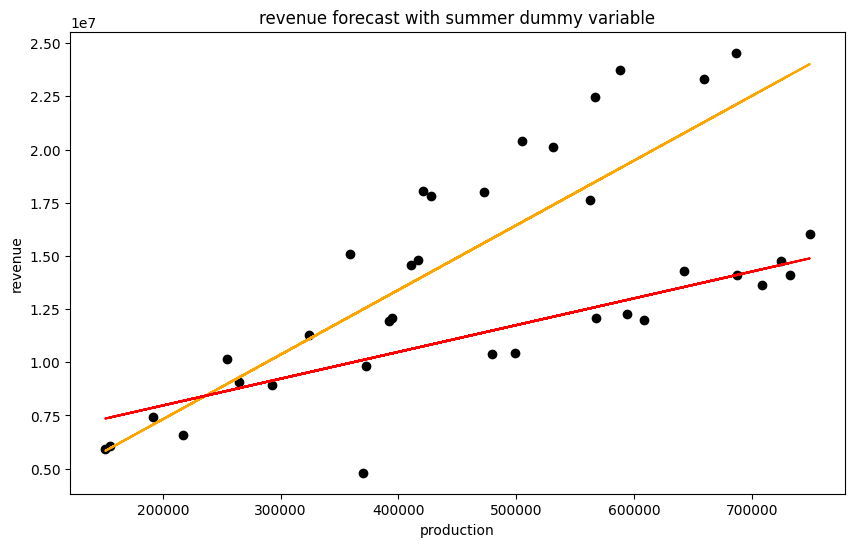

In [39]:
plt.figure(figsize = (10,6))

plt.title('revenue forecast with summer dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

#step 1 for visualizing a regression with dummy variables is to scatter plot the actial datapoints

plt.scatter(dt4training['production'], dt4training['revenue'], color='black')

#step 2 is to extract the coefficients from our model
intercept, production_coefficient, summer_DV_intercept, summer_coefficient = model2.params

#Step 3 is to create lines for winter and non winter
non_summer_line = intercept + production_coefficient * dt4training2['production']

summer_line = (intercept + summer_DV_intercept) + (production_coefficient + summer_coefficient) * dt4training2['production']

#step 4 plot the winter and non winter lines

plt.plot(dt4training2['production'],non_summer_line, color = 'orange')
plt.plot(dt4training2['production'], summer_line, color = 'red')